## Convolution

### 1. 1D -- show examples

- smoothing

- picking out features
    - show different kernels picking out different features (sawtooth, top-hat, gaussian)
    - receptive field
    - two convolution layer -- picking out higher level features, like a human, a plate to infer the activity of eating 
    - why the pooling layer makes sense -- if you have a perfect match between the filter and your image, the convolution gives you a spike.
### 2. 2D -- show examples

### 3. Convolutional Neural Net


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [4, 3]

In [2]:
import numpy as np

h = [2, 1, 0]
x = [3, 4, 5]
 

y = np.convolve(x, h)
y  

array([ 6, 11, 14,  5,  0])

sliding x window over h -- i.e., dot product between x and t, with x moving across h, and note how h comes in "backward"!
<ul>
    <li>6  = 2 * 3 :            
        $
        \begin{bmatrix}
             3 & 4 & 5 \\
        \end{bmatrix}
        \\ 
        \begin{bmatrix}
             2 & 0 & 0 \\
        \end{bmatrix}
        $ 
    </li>
    <li>11 = 1 * 3 + 2 * 4 :
        $
        \begin{bmatrix}
             3 & 4 & 5 \\
        \end{bmatrix}
        \\
        \begin{bmatrix}
             1 & 2 & 0 \\
        \end{bmatrix}
        $ 
    </li>  
    <li>14 = 0 * 3 + 1 * 4 + 2 * 5 :
        $
        \begin{bmatrix}
             3 & 4 & 5 \\
        \end{bmatrix}
        \\
        \begin{bmatrix}
             0 & 1 & 2 \\
        \end{bmatrix}
        $ 
    </li>  
    <li>5  = 0 * 4 + 1 * 5 :
        $
        \begin{bmatrix}
             3 & 4 & 5 \\
        \end{bmatrix}
        \\
        \begin{bmatrix}
             0 & 0 & 1 \\
        \end{bmatrix}
        $ 
    </li>
    <li>0  = 0 * 5 :
        $
        \begin{bmatrix}
             3 & 4 & 5 \\
        \end{bmatrix}
        \\
        \begin{bmatrix}
             0 & 0 & 0 \\
        \end{bmatrix}
        $ 
    </li>
</ul>

<h4> Now we are going to verify what Python did, because we don't trust computer outputs while we are learning. Using the equation of convolution for y[n]:</h4>
  
$$y[n] = \sum\limits_{k\to-\infty}^\infty x[k] \cdot h[n-k] $$


And then, manually executing computation:

$ 
y[0]= \sum\limits_{k\to-\infty}^\infty x[k]\cdot h[0-k]= x[0]\cdot h[0]=3\cdot 2=6 \\
y[1]= \sum\limits_{k\to-\infty}^\infty x[k]\cdot h[1-k]= x[0]\cdot h[1-0]+x[1]\cdot h[1-1] + \space... \\ 
\qquad\qquad\qquad\qquad\qquad   = x[0]\cdot h[1] + x[1]\cdot h[0]= 3\cdot1+4\cdot 2=11 \\
y[2]= \sum\limits_{k\to-\infty}^\infty x[k]\cdot h[2-k]= x[0]\cdot h[2-0]+x[1]\cdot h[2-1]+x[2]\cdot h[2-2]+ \space ... \\ 
\qquad\qquad\qquad\qquad\qquad   = x[0]\cdot h[2] + x[1]\cdot h[1]+x[2]\cdot h[0]= 3\cdot0+4\cdot 1 +5\cdot 2=14 \\
y[3]= \sum\limits_{k\to-\infty}^\infty x[k]\cdot h[3-k]= x[0]\cdot h[3-0]+x[1]\cdot h[3-1]+x[2]\cdot h[3-2]+ x[3]\cdot h[3-3] + \space... \\ 
\qquad\qquad\qquad\qquad\qquad   = x[0]\cdot h[3] +x[1]\cdot h[2] + x[2]\cdot h[1]+x[3]\cdot h[0]=0+0+5 \cdot 1 +0=5 \\
y[4]= \sum\limits_{k\to-\infty}^\infty x[k]\cdot h[4-k]= x[0]\cdot h[4-0]+x[1]\cdot h[4-1]+x[2]\cdot h[4-2]+\space... =0\\ 
$


## Mathematical shorthand for convolution between two functions, $f$ and $g$:

## $$f*g$$

There are three methods to apply kernel on the matrix, <b>with padding (full)</b>, <b>with padding(same)</b> and <b>without padding(valid)</b>:  

</h3>1) Visually understanding the operation with padding (full)</h3>

Lets think of the kernel as a sliding window. We have to come with the solution of padding zeros on the input array. This is a very famous implementation and will be easier to show how it works with a simple example, consider this case:
  
x[i] = [6,2]  
h[i] = [1,2,5,4]  

Using the zero padding, we can calculate the convolution.
 
You have to either **invert** the filter x or the data, otherwise the operation would be cross-correlation.  Here we invert x -- this is fairly typical.
First step, (now with zero padding): 

= 2 \* 0 + 6 * 1 = 6 
 
Second step:

= 2 \* 1 + 6 * 2 = 14 (the arrows represent the connection between the kernel and the input)

Third step:

= 2 \* 2 + 6 * 5 = 34  
  
Fourth step:

Final step:

= 2 \* 4 + 6 * 0 = 8

The result of the convolution for this case, listing all the steps, would then be: Y = [6 14 34 34 8]

Below we verify with numpy:

In [3]:
import numpy as np

x = [6, 2]
h = [1, 2, 5, 4]

y = np.convolve(x, h, "full")  #now, because of the zero padding, the final dimension of the array is bigger
y  

array([ 6, 14, 34, 34,  8])

<h3>2) Visually understanding the operation with "same"</h3>
In this approach, we just add the zero to left (and top of the matrix in 2D). 

That is, you add zeros at the beginning of your input data.


In effect, only the first 4 steps of "full" method:

In [4]:
import numpy as np

x = [6, 2]
h = [1, 2, 5, 4]

y = np.convolve(x, h, "same")  # it is same as zero padding, but with returns an ouput with the same length as max of x or h
y  

array([ 6, 14, 34, 34])

<h3>3) Visually understanding the operation with no padding (valid)</h3>

In the last case we only applied the kernel when we had a compatible position on the h array, in some cases you want a dimensionality reduction. For this purpose, we simple ignore the steps that would need padding:
    
x[i] = [6 2] 

h[i] = [1 2 5 4]

You have to invert the filter x, otherwise the operation would be cross-correlation.
First step, (now without zero padding):

In [5]:
import numpy as np

x = [6, 2]
h = [1, 2, 5, 4]

y = np.convolve(x, h, "valid")   # valid returns output of length max(x, h) - min(x, h) + 1, this is to ensure that values outside of the boundary of 
                                # h will not be used in the calculation of the convolution
                                # in the next example we will understand why we used the argument valid
y  

array([14, 34, 34])

The 2D convolution operation is defined as:

<font size="4">$$ I'= \sum\limits_{u,v} I(x-u,y-v)g(u,v) $$ </font> 
 

## 1-D Kernel
 
Below we will apply the equation to an image represented by a 3x3 matrix according to the function g = (-1 1). Please note that when we apply the kernel we always use its inversion. 
 
$
I=
\begin{bmatrix}
     255          & 7      & 3     \\
     212          & 240    & 4     \\
     218          & 216    & 230
\end{bmatrix}
\\
$ 

$
g=
\begin{bmatrix}
     -1          & 1      
\end{bmatrix}
\\
$ 
  
$
\begin{bmatrix}
    \textbf{1}\cdot \textbf{0}      & \textbf{-1} \ast \textbf{255}  & 7      & 3     \\
    0              & 212          & 240    & 4     \\
    0              & 218          & 216    & 230
\end{bmatrix}
\rightarrow
\begin{bmatrix}
    \textbf{-255}  & 7      & 3     \\
    212            & 240    & 4     \\
    218            & 216    & 230
\end{bmatrix}
\\
$

$
\begin{bmatrix}
    \textbf{1}\ast \textbf{255}      & \textbf{-1} \ast \textbf{7}  & 3    \\
    212          & 240    & 4     \\
    218          & 216    & 230
\end{bmatrix}
\rightarrow
\begin{bmatrix}
    -255           & \textbf{248}      & 3     \\
    212            & 240    & 4     \\
    218            & 216    & 230
\end{bmatrix}
\\
$

$
\begin{bmatrix}
    255          & \textbf{1}\ast\textbf{7}  & \textbf{-1}\ast\textbf{3}    \\
    212          & 240    & 4     \\
    218          & 216    & 230
\end{bmatrix}
\rightarrow
\begin{bmatrix}
    -255           & 248      & \textbf{4}     \\
    212            & 240      & 4     \\
    218            & 216      & 230
\end{bmatrix}
\\
$

  
$
\begin{bmatrix}
    0              & 255          & 7          & 3     \\
    \textbf{1}\ast \textbf{0}    & \textbf{-1} \ast \textbf{212}  & 240     & 4     \\
    0              & 218          & 216    & 230
\end{bmatrix}
\rightarrow
\begin{bmatrix}
    \textbf{-255}  & 248    & 4     \\
    -212            & 240    & 4     \\
    218            & 216    & 230
\end{bmatrix}
\\
$
 
 


In [6]:
from scipy import signal as sg

I= [[255,   7,  3],
    [212, 240,  4],
    [218, 216, 230],]

g= [[-1, 1]]

print('Without zero padding \n')
print('{0} \n'.format(sg.convolve( I, g, 'valid')))
# The 'valid' argument states that the output consists only of those elements 
# that do not rely on the zero-padding.

print('With zero padding \n')
print(sg.convolve( I, g, 'full'))


print('With zero padding_same \n')
print(sg.convolve( I, g, 'same'))

Without zero padding 

[[248   4]
 [-28 236]
 [  2 -14]] 

With zero padding 

[[-255  248    4    3]
 [-212  -28  236    4]
 [-218    2  -14  230]]
With zero padding_same 

[[-255  248    4]
 [-212  -28  236]
 [-218    2  -14]]


For a more difficult case where h= [ [-1  1] , [2   3] ]

$
\begin{bmatrix}
    \textbf{3}\ast \textbf{0}      & \textbf{2} \ast \textbf{0}     & 0      & 0     \\
    \textbf{1}\ast \textbf{0}      & \textbf{-1} \ast \textbf{255}  & 7      & 3     \\
    0              & 212          & 240    & 4     \\
    0              & 218          & 216    & 230
\end{bmatrix}
\rightarrow
\begin{bmatrix}
    \textbf{-255}  & 7      & 3     \\
    212            & 240    & 4     \\
    218            & 216    & 230
\end{bmatrix}
\\
$

## 2D Kernel

In [7]:
from scipy import signal as sg

I= [[255,   7,  3],
    [212, 240,  4],
    [218, 216, 230],]

g= [[-1,  1],
    [ 2,  3],]

print ('With zero padding \n')
print ('{0} \n'.format(sg.convolve( I, g, 'full')))
# The output is the full discrete linear convolution of the inputs. 
# It will use zero to complete the input matrix

print ('With zero padding_same_ \n')
print ('{0} \n'.format(sg.convolve( I, g, 'same')))
# The output is the full discrete linear convolution of the inputs. 
# It will use zero to complete the input matrix


print ('Without zero padding \n')
print (sg.convolve( I, g, 'valid'))
# The 'valid' argument states that the output consists only of those elements 
#that do not rely on the zero-padding.

With zero padding 

[[-255  248    4    3]
 [ 298  751  263   13]
 [ 206 1118  714  242]
 [ 436 1086 1108  690]] 

With zero padding_same_ 

[[-255  248    4]
 [ 298  751  263]
 [ 206 1118  714]] 

Without zero padding 

[[ 751  263]
 [1118  714]]


## What is convolution good for?

### 1. Smoothing
### 2. Picking out features

## Pay atttention to normalization -- smoothing

## - use 'same"

## - note that convolution is symmetric w.r.t. the functions

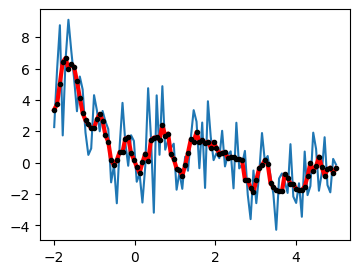

In [8]:
'''
initial drop is due to zero padding
'''

x = np.linspace(-2, 5, 100)
y = np.exp(-x) + np.random.randn(x.shape[0])*2
np.random.seed(0)

plt.plot(x, y)

kern = np.ones(5)/5

y_smoothed = np.convolve(y, kern, 'same')
plt.plot(x, y_smoothed, 'r', lw=3)

conv_reverse_order = np.convolve(kern, y,  'same')

plt.plot(x, conv_reverse_order, 'k.', lw=2)


## Picking out features -- example: edge detection

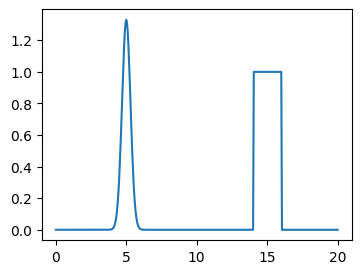

In [9]:
x = np.linspace(0, 20, 401)
y1 = norm.pdf(x[:201], 5, 0.3)
y2 = np.concatenate((np.repeat(0, 80), np.repeat(1, 40), np.repeat(0, 80)))

y = np.concatenate((y1, y2))

plt.plot(x, y)

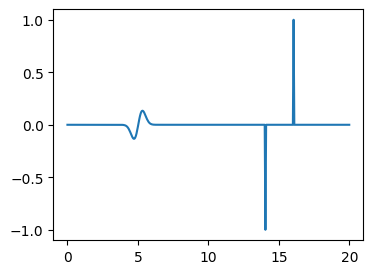

In [10]:
'''
specalized kernels as edge detector -- soft edge vs. sharp edge

You may think your job is to find the best kernels for an application, i.e., kernel engineering

But CNN saves you from that work!

'''

edge_kern = np.array([-1, 1])

y_conv = np.convolve(y, edge_kern, 'same')

x.shape, y_conv.shape
plt.plot(x, y_conv)

## Breakout exercise

### Find the convolution of a tophat function and a triangle function

## Recall:

$$y[n] = \sum\limits_{k\to-\infty}^\infty x[k] \cdot h[n-k] $$

$$h: \mathrm{data}$$

$$x: \mathrm{kernel}$$ 

## Breakout -- show how kernel moves across the signal for the convolution of a two-sided triangle and an exponential function -- both defined on 

### $$x \in [-5, 5]$$

### Write a function: 

`convolution_steps(f1, f2, t0)`

### where t0 is the separation between the highest point of the exponential funtion the the triangle function

### Step t0 through -1.5 and 1.5 and show how the convolution result evolves.

### for the summation over 'k', you can use a for loop, or if you are adventuous, you can use a function from 

`scipy.integrate`

## End of Week 11-2